In [1]:
from mtpy import MTData
from mtpy.modeling.simpeg.recipes.inversion_2d import Simpeg2D
from mtpy_data import PROFILE_LIST
import numpy as np

In [2]:
md = MTData()
md.add_station([fn for fn in PROFILE_LIST if fn.name.startswith("16")])
# australian epsg
md.utm_epsg = 4462

# extract profile
profile = md.get_profile(149.15, -22.3257, 149.20, -22.3257, 1000)
# interpolate onto a common period range
new_periods = np.logspace(-3, 0, 4)
profile.interpolate(new_periods, inplace=True, bounds_error=False)
profile.compute_model_errors()

simpeg_2d_data = profile.to_simpeg_2d()






26:06:01T23:01:36 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:06:01T23:01:36 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:06:01T23:01:36 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:06:01T23:01:36 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:06:01T23:01:36 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>


In [3]:
profile.station_locations

,survey,station,latitude,longitude,elevation,datum_epsg,east,north,utm_epsg,model_east,model_north,model_elevation,profile_offset
0,0,16122A,-22.325611,149.174361,210.0,4326,1.748273e+06,392386.550646,4462,0.0,0.0,0.0,0.000000
1,0,16123A,-22.325556,149.179056,213.0,4326,1.748748e+06,392327.275727,4462,0.0,0.0,0.0,479.364239
2,0,16124A,-22.325694,149.184472,212.0,4326,1.749294e+06,392236.788159,4462,0.0,0.0,0.0,1032.475708
3,0,16125A,-22.325750,149.189306,219.0,4326,1.749782e+06,392163.460126,4462,0.0,0.0,0.0,1526.021071
4,0,16126A,-22.325806,149.194000,214.0,4326,1.750256e+06,392092.047703,4462,0.0,0.0,0.0,2005.383618
5,0,16127A,-22.325889,149.198861,220.0,4326,1.750747e+06,392015.275517,4462,0.0,0.0,0.0,2501.763932


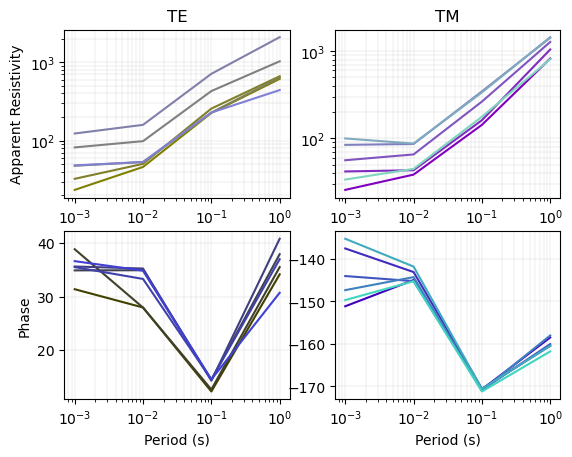

In [4]:
simpeg_2d_data.plot_response()

In [5]:
mt_df = profile.to_dataframe(impedance_units="ohm")

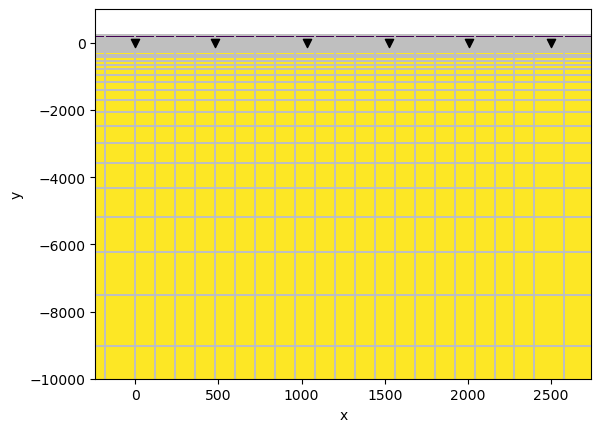

In [6]:
n_iterations = 10

simpeg_inversion = Simpeg2D(
    mt_df,
    max_iterations=n_iterations,
    data_kwargs={"include_elevation": False},
)

In [7]:
inv_output = simpeg_inversion.run_inversion()

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DMagneticField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.39e-01  8.11e+03  0.00e+00  8.11e+03                                 
   1  6.39e-01  2.88e+03  3.22e+01  2.90e+03    1.95e+03      0              
   2  3.20e-01  4.37e+02  5.03e+01  4.53e+02    5.26e+02      0              
   3  1.60e-01  3.10e+02  7.77e+01  3.22e+02    9.06e+01      1   Skip BFGS  
   4  7.99e-02  2.13e+02  1.21e+02  2.23e+02    1.11e+02      0   Skip BFGS  
   5  3.99e-02  1.91e+02  1.59e+02  1.98e+02    2.70e+01      1   Skip BFGS  
   6  2.00e-02  1.81e+02  1.82e+02  1.85e+02    3.88e+01      2   Skip BFGS  
   7  9.99e-03  1.73e+02  2.11e+02  1.75e+02    4.31e+01      2   Skip BFGS  
   8  4.99e-03  1.72e+02  2.69e+02  1.73e+02    5.29e+01      1   Skip BFGS  
   9  2.50e-03  1.56e+02

In [8]:
inv_output

array([-4.32179953, -4.34255624, -4.35237074, ..., -4.93638829,
       -2.93946254, -2.98731354], shape=(1520,))

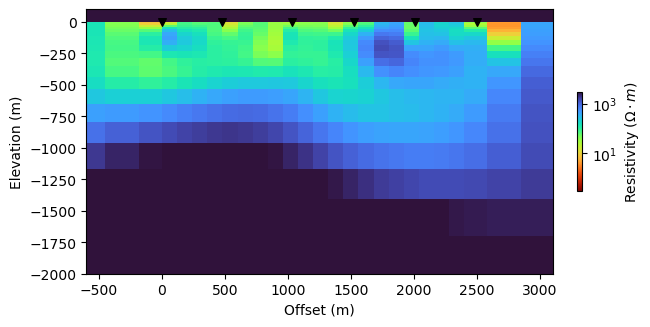

In [9]:
simpeg_inversion.plot_iteration(n_iterations, z_limits=(-2000, 100))

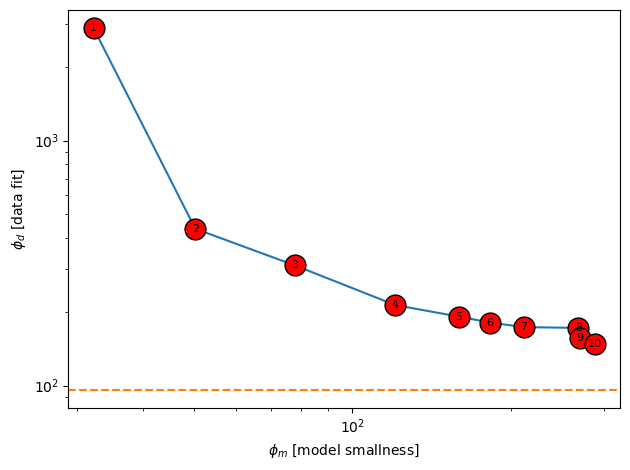

In [10]:
simpeg_inversion.plot_tikhonov_curve()

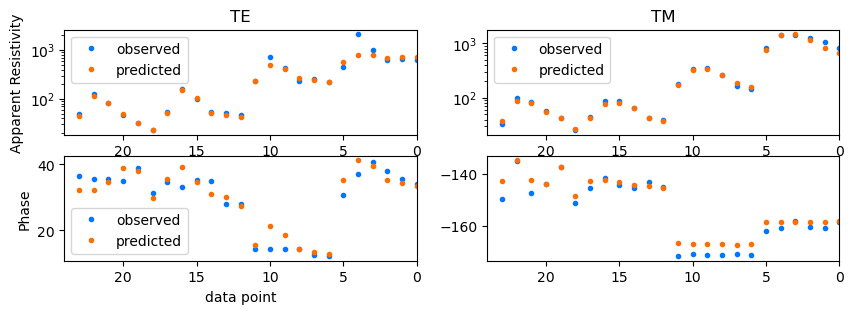

In [11]:
simpeg_inversion.plot_responses(n_iterations)